<a href="https://qworld.net" target="_blank" align="left"><img src="../../qworld/images/header.jpg"  align="left"></a>
$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\braket}[2]{\langle #1|#2\rangle} $
$ \newcommand{\dot}[2]{ #1 \cdot #2} $
$ \newcommand{\biginner}[2]{\left\langle #1,#2\right\rangle} $
$ \newcommand{\mymatrix}[2]{\left( \begin{array}{#1} #2\end{array} \right)} $
$ \newcommand{\myvector}[1]{\mymatrix{c}{#1}} $
$ \newcommand{\myrvector}[1]{\mymatrix{r}{#1}} $
$ \newcommand{\mypar}[1]{\left( #1 \right)} $
$ \newcommand{\mybigpar}[1]{ \Big( #1 \Big)} $
$ \newcommand{\sqrttwo}{\frac{1}{\sqrt{2}}} $
$ \newcommand{\dsqrttwo}{\dfrac{1}{\sqrt{2}}} $
$ \newcommand{\onehalf}{\frac{1}{2}} $
$ \newcommand{\donehalf}{\dfrac{1}{2}} $
$ \newcommand{\hadamard}{ \mymatrix{rr}{ \sqrttwo & \sqrttwo \\ \sqrttwo & -\sqrttwo }} $
$ \newcommand{\vzero}{\myvector{1\\0}} $
$ \newcommand{\vone}{\myvector{0\\1}} $
$ \newcommand{\stateplus}{\myvector{ \sqrttwo \\  \sqrttwo } } $
$ \newcommand{\stateminus}{ \myrvector{ \sqrttwo \\ -\sqrttwo } } $
$ \newcommand{\myarray}[2]{ \begin{array}{#1}#2\end{array}} $
$ \newcommand{\X}{ \mymatrix{cc}{0 & 1 \\ 1 & 0}  } $
$ \newcommand{\I}{ \mymatrix{rr}{1 & 0 \\ 0 & 1}  } $
$ \newcommand{\Z}{ \mymatrix{rr}{1 & 0 \\ 0 & -1}  } $
$ \newcommand{\Htwo}{ \mymatrix{rrrr}{ \frac{1}{2} & \frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} & \frac{1}{2} } } $
$ \newcommand{\CNOT}{ \mymatrix{cccc}{1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0} } $
$ \newcommand{\norm}[1]{ \left\lVert #1 \right\rVert } $
$ \newcommand{\pstate}[1]{ \lceil \mspace{-1mu} #1 \mspace{-1.5mu} \rfloor } $
$ \newcommand{\greenbit}[1] {\mathbf{{\color{green}#1}}} $
$ \newcommand{\bluebit}[1] {\mathbf{{\color{blue}#1}}} $
$ \newcommand{\redbit}[1] {\mathbf{{\color{red}#1}}} $
$ \newcommand{\brownbit}[1] {\mathbf{{\color{brown}#1}}} $
$ \newcommand{\blackbit}[1] {\mathbf{{\color{black}#1}}} $

# QML Pipeline Template (Toy Example)

_Prepared by Claudia Zendejas-Morales_

This notebook turns the abstract idea of a QML pipeline into a concrete, leakage-safe toy example. We start from a small binary classification problem, build a classical baseline step by step, and then add a tiny variational quantum preview on the same data flow so that the notebook already contains a genuine QML branch. The goal is not to claim any type of quantum advantage from toy data, but to learn the workflow: define the task and metric, split data correctly, preprocess without leakage, train a baseline, and report results in a way that still makes sense when a quantum model is introduced.

<p align="center">
  <img style="display:block; margin-left:auto; margin-right:auto;" src="./images/ml-vs-qml-pipeline.png" alt="Classical ML pipeline compared with a hybrid QML pipeline" width="800"/>
</p>
<p align="center"><em>Most of the pipeline stays classical. The main change in QML is the model core: an encoding step, a quantum kernel or parameterized circuit, and a measurement that returns classical outputs.</em></p>

## Pipeline template (general)

A practical QML workflow usually contains the following steps:
1. **Define the task and success metric**: decide whether the task is classification, regression, clustering, or generative modeling, and choose metrics that match that goal.
2. **Split the data before preprocessing**: separate train, validation, and test data before fitting preprocessors or models.
3. **Build a leakage-safe classical baseline**: establish a simple reference model on properly preprocessed training data.
4. **Choose where the quantum branch enters**: decide whether the first quantum model should be kernel-based, variational, or generative.
5. **Evaluate and summarize results**: compare validation and test behavior under the same split and the same metrics, then report the main takeaways clearly.
6. **Stress-test the pipeline**: change the data or task difficulty to see where the current baseline starts to fail.

In a larger project, one would usually make the quantum training setup more explicit as well, including the loss function, optimizer, backend, shots, or kernel-evaluation strategy. In this introductory notebook, that part is only previewed because the quantum model itself is not trained yet.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_circles, make_classification, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay

In [2]:
# Helper plot: visualize the train/validation/test split used by the pipeline.
def plot_split(X_train, y_train, X_val, y_val, X_test, y_test, title):
    plt.figure(figsize=(5.8, 4.8))
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="coolwarm", alpha=0.45, label="train")
    plt.scatter(X_val[:, 0], X_val[:, 1], c=y_val, cmap="coolwarm", marker="x", s=65, label="val")
    plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap="coolwarm", marker="^", s=55, label="test")
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend()
    plt.show()


# Helper plot: inspect the classifier's decision regions in the original feature plane.
def plot_decision_boundary(model, scaler, X, y, title):
    x1_min, x1_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
    x2_min, x2_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0
    xx, yy = np.meshgrid(
        np.linspace(x1_min, x1_max, 300),
        np.linspace(x2_min, x2_max, 300),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_scaled = scaler.transform(grid)
    zz = model.predict(grid_scaled).reshape(xx.shape)
    classes = np.unique(y)
    levels = np.arange(classes.min() - 0.5, classes.max() + 1.5, 1)

    plt.figure(figsize=(5.8, 4.8))
    plt.contourf(xx, yy, zz, levels=levels, alpha=0.22, cmap="coolwarm")
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k", alpha=0.8)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

## Step 1: Define the task and metric

We use a small supervised classification dataset
$$
\mathcal{D} = \{(\vec{x}_i, y_i)\}_{i=1}^{N}, \qquad \vec{x}_i \in \mathbb{R}^2, \; y_i \in \{0,1\}
$$
The baseline model will produce a prediction $\hat{y}_i = f_{\theta}(\vec{x}_i)$, and we will evaluate it with **accuracy** and **F1**. In a tiny tutorial example these metrics are enough to illustrate the pipeline, while later sections will let us compare the same task under quantum models.

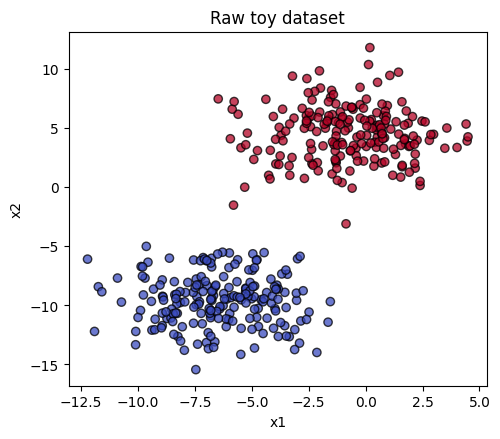

In [3]:
# A simple 2D binary dataset
X, y = make_blobs(
    n_samples=400,
    centers=2,
    cluster_std=2.2,
    random_state=11,
)

plt.figure(figsize=(5.4, 4.6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k", alpha=0.75)
plt.title("Raw toy dataset")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

## Step 2: Split before preprocessing

<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Leakage-Safe Pipeline</b><br>
A pipeline is called <i>leakage-safe</i> when information from validation or test data is not used while fitting preprocessors or models. In practice, this usually means we split the data first, fit transformations such as <code>StandardScaler</code> only on the training set, and apply the fitted transformation to validation and test later. For a standard reference, see scikit-learn's <a href="https://scikit-learn.org/stable/common_pitfalls.html#data-leakage">data leakage</a> note.
</div>

<br>

<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Why Three Splits?</b><br>
The <u>training set</u> is used to fit model parameters, the <u>validation set</u> is used to compare design choices such as hyperparameters or model families, and the <u>test set</u> is kept untouched until the very end for a final evaluation. In the code below, this is implemented with <i>two</i> calls to <code>train_test_split</code>: first we hold out <code>X_test</code>, and then we split the remaining temporary pool <code>X_temp</code> into <code>X_train</code> and <code>X_val</code>. This is a standard way to build three subsets from one dataset.
</div>

<br>

A leakage-safe pipeline always splits the data first. We create train, validation, and test subsets, and only after that do we fit the scaler on the training set. In the code below, <code>X_temp</code> is not a final subset of the pipeline: it is simply the temporary pool that still contains the future training and validation data after the test set has been held out. If $S$ denotes the fitted preprocessing map, then the rule is
$$
\vec{z}_i = S(\vec{x}_i), \qquad S \text{ is fitted only on } X_{\mathrm{train}}
$$
This matters just as much in QML as in classical ML. If preprocessing uses information from validation or test data, then later comparisons between a classical and a quantum model stop being reliable.

In [4]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=11,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    stratify=y_temp,
    random_state=11,
)

print("Train size:", X_train.shape[0])
print("Validation size:", X_val.shape[0])
print("Test size:", X_test.shape[0])

Train size: 240
Validation size: 80
Test size: 80


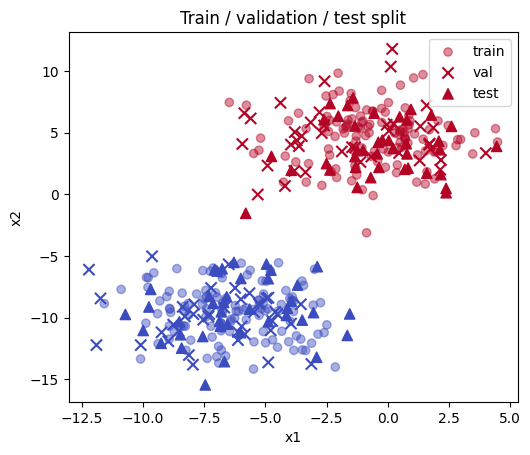

In [5]:
plot_split(X_train, y_train, X_val, y_val, X_test, y_test, "Train / validation / test split")

## Step 3: Fit a leakage-safe classical baseline

For a first baseline we use logistic regression on scaled features. If $\vec{z}$ denotes the scaled feature vector, then the model has the form
$$
p_\theta(y=1\mid \vec{z}) = \sigma(\vec{w}^{\top}\vec{z}+b)
$$
and the predicted class is
$$
\hat{y} = \mathbf{1}\big(p_\theta(y=1\mid \vec{z}) \geq 1/2\big)
$$
Here $p_\theta(y=1\mid \vec{z})$ is the model's estimated probability that the input belongs to class $1$, given the feature vector $\vec{z}$ and the model parameters $\theta = (\vec{w}, b)$. The term $\vec{w}^{\top}\vec{z}$ is the dot product between the weight vector and the input, so it forms a weighted sum of the features, while $b$ is a bias term that shifts the decision boundary. The function $\sigma(t)=\dfrac{1}{1+e^{-t}}$ is the sigmoid, which maps any real number into the interval $(0,1)$ so that the output can be interpreted as a probability.

The prediction rule $\hat{y} = \mathbf{1}\big(p_\theta(y=1\mid \vec{z}) \geq 1/2\big)$ should be read as follows: assign label $1$ when the predicted probability is at least $0.5$, and assign label $0$ otherwise. The symbol $\mathbf{1}(\cdot)$ is an indicator function, so it returns $1$ when the condition inside is true and $0$ when it is false.

This is not meant to be the final model of the course. It is the baseline we will later compare against when we try a quantum kernel or a variational quantum classifier.

<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Logistic Regression</b><br>
Logistic regression is a standard classification model that converts a linear score into a class probability through the sigmoid function. Despite its name, it is mainly used for classification, especially binary classification. For a concise reference, see <a href="https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression">scikit-learn's logistic regression documentation</a> or the <a href="https://en.wikipedia.org/wiki/Logistic_regression">Wikipedia overview</a>.
</div>

In [6]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

baseline = LogisticRegression(max_iter=1500, random_state=11)
baseline.fit(X_train_s, y_train)

y_val_pred = baseline.predict(X_val_s)
y_test_pred = baseline.predict(X_test_s)

val_acc = accuracy_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print(f"Validation accuracy: {val_acc:.3f}")
print(f"Validation F1: {val_f1:.3f}")
print(f"Test accuracy: {test_acc:.3f}")
print(f"Test F1: {test_f1:.3f}")

Validation accuracy: 1.000
Validation F1: 1.000
Test accuracy: 0.988
Test F1: 0.987


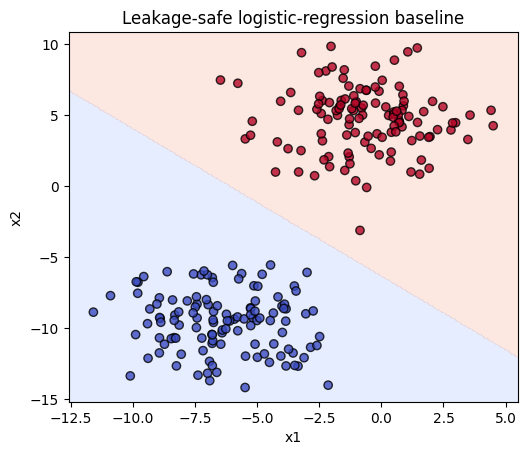

In [7]:
plot_decision_boundary(
    baseline,
    scaler,
    X_train,
    y_train,
    "Leakage-safe logistic-regression baseline",
)

This is already enough to expose the basic logic of the pipeline: define a task, split first, preprocess safely, train a baseline, and evaluate it with explicit metrics. The same discipline will still be required when the model core becomes quantum.

### Task 1 (coding): Extend the same pipeline to a three-class toy problem

Now apply the same leakage-safe pipeline to a small **three-class** dataset generated with `make_classification`:
- `n_samples=600`
- `n_features=2`
- `n_informative=2`
- `n_redundant=0`
- `n_repeated=0`
- `n_classes=3`
- `n_clusters_per_class=1`
- `class_sep=1.4`
- `random_state=23`

This is a first easy extension from binary classification to multiclass classification. The pipeline logic should stay the same, but the evaluation should now use `macro-F1`, for example with `f1_score(..., average="macro")`.

Tasks:
- create a train/validation/test split,
- fit `StandardScaler` on the training set only,
- train a logistic-regression baseline,
- report validation and test `accuracy` and `macro-F1`,
- produce one informative plot of either the split or the decision boundary,
- and write one short sentence saying whether the linear baseline still looks reasonable for this dataset.

<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 1 solution:</b> <a href="04-qml-pipeline-template-toy-example-solutions.ipynb#task1-solution">Click here for Task 1 solution</a>
</div>

In [8]:
# Task 1 starter
X_task1, y_task1 = make_classification(
    n_samples=600,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_repeated=0,
    n_classes=3,
    n_clusters_per_class=1,
    class_sep=1.4,
    random_state=23,
)

# Split the data into train, validation, and test.
# Fit the scaler on the training split only.
# Train a logistic-regression baseline and report accuracy plus macro-F1.
# Finally, make one informative plot and add one short interpretation sentence.

## Step 4: Where does the quantum branch enter?

The point of a pipeline template is that most steps stay the same even when the model changes. In QML, the main change is the model core.

A common QML language is to treat data encoding as a **feature map**:
$$
|\phi(\vec{x})\rangle = U_F(\vec{x})|0\cdots 0\rangle
$$
Here $\vec{x}$ is a classical input sample and $U_F(\vec{x})$ is an encoding unitary that maps that sample into a quantum state. From there, two natural directions are:
- **Kernel branch**: compare two encoded samples $\vec{x}$ and $\vec{x}^{\prime}$ through a quantum kernel such as
$$
k(\vec{x},\vec{x}^{\prime}) = |\langle \phi(\vec{x}) \mid \phi(\vec{x}^{\prime}) \rangle|^2
$$
  where $k(\vec{x},\vec{x}^{\prime})$ is a similarity score between the two encoded states.
- **Variational branch**: pass the encoded state through a parameterized circuit and measure a classical output,
$$
\hat{y} = g_{\theta}(\vec{x})
$$
  where $g_{\theta}$ denotes a trainable model with parameters $\theta$.

At this stage these are only first working definitions. Later sections of this QML tutorial will explain feature maps, quantum kernels, and variational circuits in much more detail, including why one chooses particular encodings, gates, and measurements.

Notice what does **not** change: the task definition, the split strategy, the baseline comparison, and the evaluation metrics. That is why it is useful to build the classical pipeline first.

### A tiny variational preview on the same split

To make the notebook already contain a real QML component, we now replace the model core by a minimal one-qubit variational circuit evaluated on the **scaled** validation features from the previous step. Here $\vec{z}=(z_1,z_2)$ denotes the scaled version of a two-dimensional sample. We define
$$
|\psi_\theta(\vec{z})\rangle = R_Y(\theta)R_Z(z_2)R_Y(z_1)|0\rangle
$$
measure
$$
s_\theta(\vec{z}) = \langle \psi_\theta(\vec{z})|Z|\psi_\theta(\vec{z})\rangle
$$
and convert that into a class score through
$$
p_\theta(y=1\mid \vec{z}) = \frac{1-s_\theta(\vec{z})}{2}, \qquad \hat{y} = \mathbf{1}\big(p_\theta(y=1\mid \vec{z}) \geq 1/2\big)
$$
The quantity $s_\theta(\vec{z})$ is the expectation value of the observable $Z$, so it is a real number between $-1$ and $1$ summarizing the circuit's output before we map it to a class probability. Also note the operator order in the state expression: operators act on kets from right to left, so the gate written closest to $|0\rangle$ is the one applied first.

This is only a preview, not a competitive model. Its job here is to show concretely how a quantum circuit can sit inside the same train/validation/test workflow.

<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Do Not Worry About the Gate Choices Yet</b><br>
At this point it is normal if the circuit still feels somewhat arbitrary. Here $R_Y(z_1)$ and $R_Z(z_2)$ simply give us a minimal way to inject two scaled features into one qubit, and the final $R_Y(\theta)$ plays the role of a trainable layer. Later sections of this tutorial will explain feature maps, variational circuits, and quantum kernels much more carefully. For now, the important point is only that the quantum part still returns a classical score that fits into the same pipeline.
</div>

In [9]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector


def variational_preview(z, theta):
    qc = QuantumCircuit(1)
    qc.ry(z[0], 0)
    qc.rz(z[1], 0)
    qc.ry(theta, 0)

    state = Statevector.from_instruction(qc)
    probs = state.probabilities()
    exp_z = probs[0] - probs[1]
    p1 = probs[1]
    return qc, exp_z, p1

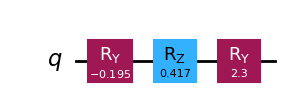

Scaled input z = [-0.19545075  0.41724481]
<Z> = -0.521
p_theta(y=1|z) = 0.761
Predicted label = 1
True label = 1


In [10]:
theta_preview = 2.3
qc_preview, exp_z_preview, p1_preview = variational_preview(X_val_s[0], theta_preview)

display(qc_preview.draw(output="mpl"))
print(f"Scaled input z = {X_val_s[0]}")
print(f"<Z> = {exp_z_preview:.3f}")
print(f"p_theta(y=1|z) = {p1_preview:.3f}")
print(f"Predicted label = {int(p1_preview >= 0.5)}")
print(f"True label = {y_val[0]}")

The first two rotations encode the two scaled features into a one-qubit state. The last rotation carries the parameter $\theta$, which in a full variational workflow would be learned from data. The measurement then converts the final quantum state back into a classical scalar, so the rest of the pipeline can stay unchanged.

Preview variational validation accuracy: 0.725
Preview variational validation F1: 0.784
This is only a fixed-parameter preview, not a trained quantum classifier.


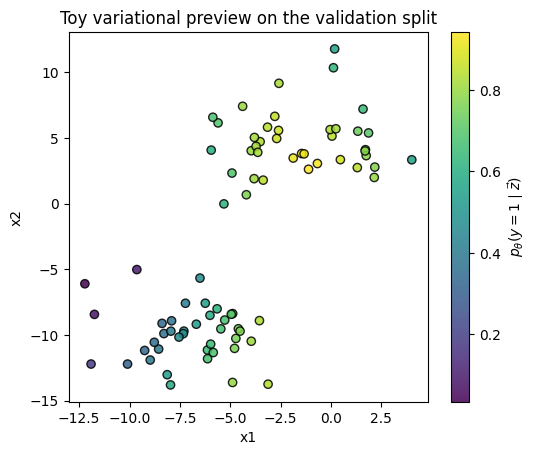

In [11]:
exp_z_val = []
p1_val = []

for z in X_val_s:
    _, exp_z, p1 = variational_preview(z, theta_preview)
    exp_z_val.append(exp_z)
    p1_val.append(p1)

exp_z_val = np.array(exp_z_val)
p1_val = np.array(p1_val)
y_val_q_preview = (p1_val >= 0.5).astype(int)

print(f"Preview variational validation accuracy: {accuracy_score(y_val, y_val_q_preview):.3f}")
print(f"Preview variational validation F1: {f1_score(y_val, y_val_q_preview):.3f}")
print("This is only a fixed-parameter preview, not a trained quantum classifier.")

plt.figure(figsize=(5.8, 4.8))
sc = plt.scatter(X_val[:, 0], X_val[:, 1], c=p1_val, cmap="viridis", edgecolor="k", alpha=0.85)
plt.colorbar(sc, label=r"$p_\theta(y=1 \mid \vec{z})$")
plt.title("Toy variational preview on the validation split")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

In this plot, the horizontal and vertical axes still represent the original two-dimensional sample, but the **color** represents a third quantity: the quantum model's score $p_\theta(y=1\mid \vec{z})$. Because this score is a probability, it varies continuously between $0$ and $1$, so the figure uses a continuous color scale rather than only two colors.

For this preview, the circuit first produces the expectation value $s_\theta(\vec{z}) = \langle Z \rangle$, and then we convert it into a probability through
$$
p_\theta(y=1\mid \vec{z}) = \frac{1-s_\theta(\vec{z})}{2}
$$
This means that brighter or darker color levels correspond to different predicted probabilities of class $1$. The final hard prediction
$$
\hat{y} = \mathbf{1}\big(p_\theta(y=1\mid \vec{z}) \geq 1/2\big)
$$
is obtained only after thresholding that continuous score: assign class $1$ when the probability is at least $0.5$, and class $0$ otherwise. So the color map shows the model's continuous output, while $\hat{y}$ is the binary decision derived from it.

This preview is enough to make this notebook with a QML toy example: a classical sample is encoded into a quantum circuit, a parameterized quantum transformation is applied, and a measurement returns a classical output. What is intentionally missing is the hard part: we have not justified this feature map, we have not trained $\theta$, and we have not compared it fairly against alternative quantum designs. Those choices are exactly what later sections on variational circuits and quantum kernels will develop.

### Task 2 (coding+interpretation): Compare a few fixed variational angles

Reuse the same one-qubit variational preview from this step, but now compare **three fixed values** of the trainable angle, for example `theta = -1.6`, `theta = 0.2`, and `theta = 1.4`.

Tasks:
- evaluate the validation split for each `theta`,
- report validation `accuracy` and `F1` for each case,
- choose the `theta` that gives the best validation behavior,
- make one probability-color plot for that chosen `theta`,
- and write a short note explaining how the continuous score $p_\theta(y=1\mid \vec{z})$ becomes the hard prediction $\hat{y}$.

These are just trial values, not theoretically privileged choices. This is not training yet. The point is simply to see that changing the circuit parameter changes the score landscape and therefore changes the final predictions.

<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 2 solution:</b> <a href="04-qml-pipeline-template-toy-example-solutions.ipynb#task2-solution">Click here for Task 2 solution</a>
</div>

In [12]:
# Task 2 starter
theta_candidates = [-1.6, 0.2, 1.4]

# For each theta:
# - evaluate the validation split with variational_preview,
# - compute accuracy and F1,
# - and store the results.
# Then choose one theta, make one probability-color plot,
# and add a short interpretation sentence.


## Step 5: Compare validation and test, then summarize

A <b>report card</b> is simply a compact evaluation summary for the current pipeline. It is not a special algorithm or object by itself: it is a short record of the metrics, one diagnostic plot, and the main interpretation we want to carry into later model comparisons.

For this notebook, plots of the full training process are not the most informative diagnostic yet. The logistic-regression baseline is fit in one optimizer call, and the quantum branch above is only a fixed-parameter preview, not a trained variational model. Later sections on variational QML will indeed use loss curves and metric traces during training. Here, a better diagnostic is to compare <code>validation</code> and <code>test</code> under the same metrics and inspect where the mistakes concentrate.

Minimal report card
validation | accuracy = 1.000 | F1 = 1.000
test       | accuracy = 0.988 | F1 = 0.987
|validation accuracy - test accuracy| = 0.012
|validation F1 - test F1| = 0.013


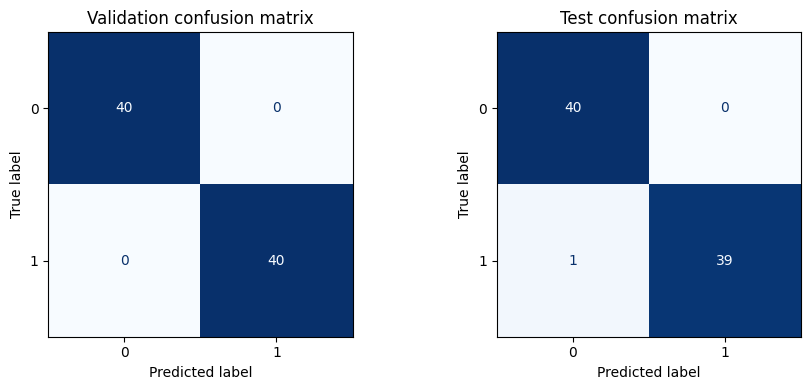

In [13]:
print("Minimal report card")
print(f"validation | accuracy = {val_acc:.3f} | F1 = {val_f1:.3f}")
print(f"test       | accuracy = {test_acc:.3f} | F1 = {test_f1:.3f}")
print(f"|validation accuracy - test accuracy| = {abs(val_acc - test_acc):.3f}")
print(f"|validation F1 - test F1| = {abs(val_f1 - test_f1):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.0))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_val_pred,
    ax=axes[0],
    colorbar=False,
    cmap="Blues",
)
axes[0].set_title("Validation confusion matrix")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    ax=axes[1],
    colorbar=False,
    cmap="Blues",
)
axes[1].set_title("Test confusion matrix")

plt.tight_layout()
plt.show()

These matrices are read by **rows = true labels** and **columns = predicted labels**. So a number on the diagonal means a correct prediction, while a number off the diagonal means a mistake. In the validation matrix, all `40` samples of class `0` are predicted as `0`, and all `40` samples of class `1` are predicted as `1`, so the diagonal is perfect and the off-diagonal entries are zero.

In the test matrix, the top row is still perfect for class `0`, but the bottom-left entry is `1`. That means **one sample whose true label is `1` was predicted as `0`**. The bottom-right entry is `39`, so the other `39` samples of class `1` were classified correctly. This is why the test performance is still very strong, but no longer perfect.

This minimal report card says more than the decision-boundary plot alone. The metric gap shows whether validation and test look aligned, and the confusion matrices show where the remaining mistakes accumulate. That is the kind of compact summary we will later want when comparing a classical baseline against a trained quantum model under the same split and the same metrics.

### Task 3 (coding+analysis): Build a clearer report card

Create a short report card for a slightly harder blob dataset with:
- `n_samples=450`
- `centers=2`
- `cluster_std=2.9`
- `random_state=31`

This time the point is not to redraw the same kind of decision-boundary plot from earlier steps. Instead, use the evaluation style from Step 5 to summarize how the model behaves across splits.

Your report card should include:
- validation and test `accuracy` plus `F1`,
- at least one confusion-matrix plot,
- one sentence saying whether validation and test behavior look consistent,
- one error-analysis note based on the matrix or the metrics,
- one limitation,
- and one next step.

A report card here simply means a compact evaluation summary that could later be compared fairly against a quantum branch under the same split and the same metrics.

<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 3 solution:</b> <a href="04-qml-pipeline-template-toy-example-solutions.ipynb#task3-solution">Click here for Task 3 solution</a>
</div>

In [14]:
# Task 3 starter
X_task3, y_task3 = make_blobs(
    n_samples=450,
    centers=2,
    cluster_std=2.9,
    random_state=31,
)

# Rebuild the leakage-safe pipeline on this harder dataset.
# Then compute validation/test accuracy and F1,
# make at least one confusion-matrix plot,
# and write a short report card comparing the two splits.

## Step 6: Stress-test the baseline

The goal of a stress test is not to produce bad numbers for their own sake. The real question is: **when performance drops, what exactly is failing?** If the split is clean, the preprocessing is leakage-safe, and the metrics are explicit, then a new failure usually points to the **model family**, not to the rest of the pipeline.

A useful way to expose that distinction is to move from roughly line-separable blobs to a dataset whose class structure depends on a **curved** rule. In such a case, the previous pipeline is still correct, but a linear baseline is no longer expressive enough. That matters for QML because later, when we introduce kernels or variational circuits, we want to know whether they are addressing a real representational limitation rather than a data-handling mistake.

In [15]:
# A nonlinear dataset that a single linear boundary cannot represent well
X_circle, y_circle = make_circles(n_samples=450, factor=0.45, noise=0.08, random_state=11)

X_temp_m, X_test_m, y_temp_m, y_test_m = train_test_split(
    X_circle,
    y_circle,
    test_size=0.2,
    stratify=y_circle,
    random_state=11,
)
X_train_m, X_val_m, y_train_m, y_val_m = train_test_split(
    X_temp_m,
    y_temp_m,
    test_size=0.25,
    stratify=y_temp_m,
    random_state=11,
)

scaler_m = StandardScaler()
X_train_m_s = scaler_m.fit_transform(X_train_m)
X_val_m_s = scaler_m.transform(X_val_m)
X_test_m_s = scaler_m.transform(X_test_m)

baseline_m = LogisticRegression(max_iter=1500, random_state=11)
baseline_m.fit(X_train_m_s, y_train_m)

y_val_m_pred = baseline_m.predict(X_val_m_s)
y_test_m_pred = baseline_m.predict(X_test_m_s)

print(f"Validation accuracy: {accuracy_score(y_val_m, y_val_m_pred):.3f}")
print(f"Validation F1: {f1_score(y_val_m, y_val_m_pred):.3f}")
print(f"Test accuracy: {accuracy_score(y_test_m, y_test_m_pred):.3f}")
print(f"Test F1: {f1_score(y_test_m, y_test_m_pred):.3f}")

Validation accuracy: 0.456
Validation F1: 0.495
Test accuracy: 0.444
Test F1: 0.432


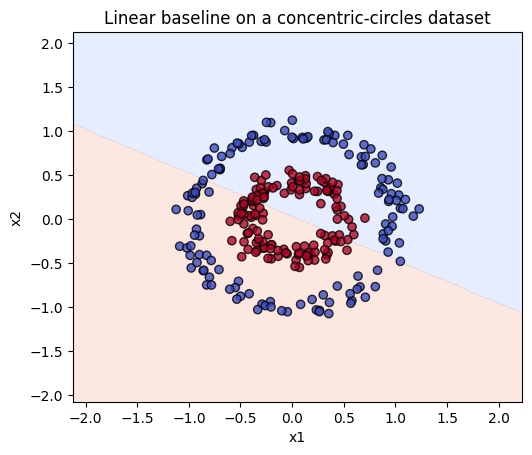

In [16]:
plot_decision_boundary(
    baseline_m,
    scaler_m,
    X_train_m,
    y_train_m,
    "Linear baseline on a concentric-circles dataset",
)

Here the main issue is not leakage, not the split, and not the metric choice. The issue is that the target pattern depends on **radius**, while logistic regression can only place one straight boundary in the original feature plane. In other words, the previous pipeline code is still doing the right job, but the current model core is too simple for this geometry.

That is why this step is useful. It tells us what kind of improvement to look for next: a richer feature representation, a nonlinear decision rule, or a similarity-based method. In this tutorial, that is exactly where quantum kernels and variational models will later enter. The point is not that QML is automatically better, but that a more expressive model class is now motivated.

### Task 4 (coding challenge): Design a different failure mode for the baseline

Do **not** reuse the concentric-circles example from Step 6 directly. Instead, build a **different** toy classification problem where the same leakage-safe logistic-regression baseline is no longer a convincing model.

Two good routes are:
- tune a noisy `make_moons` dataset until the linear baseline degrades clearly, or
- create an XOR-like four-blob dataset by relabeling diagonally opposite clusters into the same class.

Tasks:
- state the exact dataset construction you chose,
- train the same leakage-safe baseline on that dataset,
- report validation and test metrics,
- include one plot that makes the failure mode visible,
- explain whether the main issue is overlap, curvature, or label geometry,
- and then state which quantum branch you would test first (`kernel`, `variational`, or `generative`) and why.

A strong answer should make it clear that the baseline is failing for a structural reason, not just because the random split happened to be inconvenient.

<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 4 solution:</b> <a href="04-qml-pipeline-template-toy-example-solutions.ipynb#task4-solution">Click here for Task 4 solution</a>
</div>

In [17]:
# Task 4 starter
# Build a harder dataset that is NOT identical to Step 6.
# Suggested routes:
# 1. Tune a noisy make_moons dataset until logistic regression degrades clearly.
# 2. Build an XOR-like four-blob dataset and relabel diagonally opposite clusters.
#
# Then rerun the same leakage-safe pipeline, report validation/test metrics,
# add one plot, diagnose the failure mode, and choose the first quantum branch
# you would test next.